# ALS 5.3.1 Shadow4 Digital twin for blop
khchan@lbl.gov, awojdyla@lbl.gov, August 2026

using blop-env 

### Controlling the beamline via EPICS (caproto)

The degrees of freedom (DOFs) of this beamline are exposed as EPICS process variables by a standalone `caproto` IOC (`als531_shadow4_ioc.py`). Before running the cells below, start the IOC in a separate terminal:

```bash
python als531_shadow4_ioc.py
```

The IOC exposes:
- Ten DOF PVs under `ALS531S4:DOF:*` (writable; writing any value automatically triggers a re-trace of the beamline)
- An areaDetector-style camera interface under `ALS531S4:cam1:*` / `ALS531S4:image1:ArrayData`, matching the convention already used elsewhere in this repository for the real ALS 5.3.1 cameras
- A convenience scalar `ALS531S4:SIM:INTENSITY_TOTAL`

This notebook acts purely as an EPICS **client**: it writes DOF values and reads back the simulated camera image, exactly as it would for a real beamline.

## Define ophyd objects to wrap degrees of freedom existing in ophyd
make sure `als531_shadow4_ioc` is running 

In [1]:
import time
import numpy as np
import ophyd
ophyd.set_cl('caproto')
from ophyd import EpicsSignal

PREFIX = 'ALS531S4:'

# Degree-of-freedom PVs (writable; writing triggers an automatic re-trace)
dof_m1_rel_pitch_deg = EpicsSignal(PREFIX + 'DOF:M1_REL_PITCH_DEG', name='dof_m1_rel_pitch_deg')
dof_m1_bending_m = EpicsSignal(PREFIX + 'DOF:M1_BENDING_M', name='dof_m1_bending_m')
dof_mono_height_m = EpicsSignal(PREFIX + 'DOF:MONO_HEIGHT_M', name='dof_mono_height_m')
dof_mono_angle_rel_angle_deg = EpicsSignal(PREFIX + 'DOF:MONO_ANGLE_REL_ANGLE_DEG', name='dof_mono_angle_rel_angle_deg')
dof_hexapod_rel_x_m = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_X_M', name='dof_hexapod_rel_x_m')
dof_hexapod_rel_y_m = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_Y_M', name='dof_hexapod_rel_y_m')
dof_hexapod_rel_z_m = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_Z_M', name='dof_hexapod_rel_z_m')
dof_hexapod_rel_Rx_deg = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_RX_DEG', name='dof_hexapod_rel_Rx_deg')
dof_hexapod_rel_Ry_deg = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_RY_DEG', name='dof_hexapod_rel_Ry_deg')
dof_hexapod_rel_Rz_deg = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_RZ_DEG', name='dof_hexapod_rel_Rz_deg')

dof_signals = [
    dof_m1_rel_pitch_deg, dof_m1_bending_m, dof_mono_height_m, dof_mono_angle_rel_angle_deg,
    dof_hexapod_rel_x_m, dof_hexapod_rel_y_m, dof_hexapod_rel_z_m,
    dof_hexapod_rel_Rx_deg, dof_hexapod_rel_Ry_deg, dof_hexapod_rel_Rz_deg,
]

# AreaDetector-style camera PVs (read-only from the client's perspective,
# except `cam1:Acquire`, which can be used to manually force a re-trace)
cam_acquire = EpicsSignal(PREFIX + 'cam1:Acquire', name='cam_acquire')
cam_acquire_rbv = EpicsSignal(PREFIX + 'cam1:Acquire_RBV', name='cam_acquire_rbv')
cam_array_counter_rbv = EpicsSignal(PREFIX + 'cam1:ArrayCounter_RBV', name='cam_array_counter_rbv')
cam_array_size_x_rbv = EpicsSignal(PREFIX + 'cam1:ArraySizeX_RBV', name='cam_array_size_x_rbv')
cam_array_size_y_rbv = EpicsSignal(PREFIX + 'cam1:ArraySizeY_RBV', name='cam_array_size_y_rbv')
image_array_data = EpicsSignal(PREFIX + 'image1:ArrayData', name='image_array_data')
sim_intensity_total = EpicsSignal(PREFIX + 'SIM:INTENSITY_TOTAL', name='sim_intensity_total')

for sig in dof_signals + [cam_acquire, cam_acquire_rbv, cam_array_counter_rbv,
                          cam_array_size_x_rbv, cam_array_size_y_rbv,
                          image_array_data, sim_intensity_total]:
    sig.wait_for_connection(timeout=10)

print('Connected to IOC at prefix', PREFIX)


def wait_for_acquisition(poll_interval=0.2, timeout=120):
    """Block until the IOC finishes an in-progress (or about-to-start)
    beamline re-trace, i.e. until cam1:Acquire_RBV returns to 0 after
    having been seen at 1."""
    t0 = time.time()
    seen_busy = False
    while time.time() - t0 < timeout:
        busy = bool(cam_acquire_rbv.get())
        if busy:
            seen_busy = True
        elif seen_busy:
            return
        time.sleep(poll_interval)
    raise TimeoutError('Timed out waiting for beamline re-trace to complete')


def get_camera_image():
    """Read back the current camera image from the IOC and reshape it
    into a 2D (ny, nx) array."""
    nx = int(cam_array_size_x_rbv.get())
    ny = int(cam_array_size_y_rbv.get())
    flat = np.asarray(image_array_data.get())
    return flat.reshape((ny, nx))

Connected to IOC at prefix ALS531S4:


### testing the wrappers for EPICS

In [2]:
# Set degree-of-freedom values (matching the defaults previously
# hard-coded in this notebook). Writing any DOF PV automatically
# triggers the IOC to re-run the full Shadow4 beamline trace in the
# background.
dof_m1_rel_pitch_deg.put(-0.0001)
dof_m1_bending_m.put(2400)
dof_mono_height_m.put(0)
dof_mono_angle_rel_angle_deg.put(0.00)
dof_hexapod_rel_x_m.put(0)
dof_hexapod_rel_y_m.put(0)
dof_hexapod_rel_z_m.put(0)
dof_hexapod_rel_Rx_deg.put(0)
dof_hexapod_rel_Ry_deg.put(0)
dof_hexapod_rel_Rz_deg.put(0)

wait_for_acquisition()
print('Trace complete. Frame counter:', cam_array_counter_rbv.get())
print('Total intensity:', sim_intensity_total.get())

Trace complete. Frame counter: 81
Total intensity: 0.021158001064249886


### Emulating a camera
We may want to revisit how the state machine works

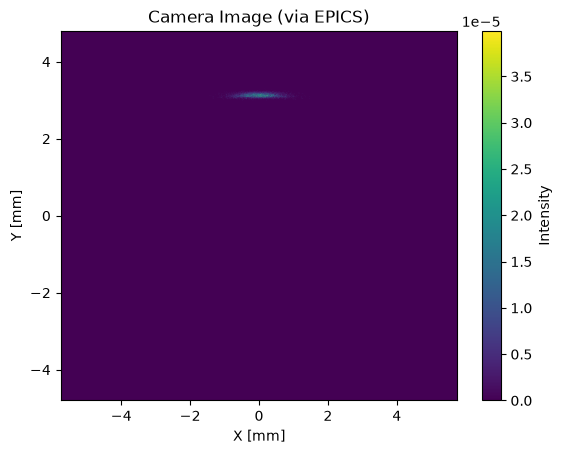

In [3]:
from als531_shadow4_sim import CAMERA_X_M, CAMERA_Y_M, CAMERA_NX, CAMERA_NY

camera_image = get_camera_image()
intensity_total = sim_intensity_total.get()

grid_x_m = np.linspace(-CAMERA_X_M / 2, CAMERA_X_M / 2, CAMERA_NX)
grid_y_m = np.linspace(-CAMERA_Y_M / 2, CAMERA_Y_M / 2, CAMERA_NY)

import matplotlib.pyplot as plt
# plot in mm
plt.imshow(camera_image, extent=[grid_x_m[0]*1e3, grid_x_m[-1]*1e3, grid_y_m[0]*1e3, grid_y_m[-1]*1e3], origin='lower', aspect='auto')
plt.xlabel('X [mm]')
plt.ylabel('Y [mm]')
plt.title('Camera Image (via EPICS)')
plt.colorbar(label='Intensity')
plt.show()

### Define an ophyd wrapper for the camera and test it

In [6]:
import threading
import time

import numpy as np
from ophyd import Device, EpicsSignal, EpicsSignalRO, Component as Cpt
from ophyd import Signal
from ophyd.status import DeviceStatus


class CamDetector(Device):
    # ── Hardware PVs ──────────────────────────────────────────────────────────
    acquire       = Cpt(EpicsSignal,   "cam1:Acquire",         kind="omitted")
    acquire_rbv   = Cpt(EpicsSignalRO, "cam1:Acquire_RBV",     kind="omitted")
    done          = Cpt(EpicsSignalRO, "cam1:Done",            kind="omitted")
    array_data    = Cpt(EpicsSignalRO, "image1:ArrayData",     kind="omitted")
    array_size_x  = Cpt(EpicsSignalRO, "cam1:ArraySizeX_RBV",  kind="omitted")
    array_size_y  = Cpt(EpicsSignalRO, "cam1:ArraySizeY_RBV",  kind="omitted")
    exposure_time = Cpt(EpicsSignal,   "cam1:AcquireTime",     kind="config")
    array_counter = Cpt(EpicsSignalRO, "cam1:ArrayCounter_RBV", kind="omitted")
    # ── Computed signals ───────────────────────────────────────────────────────
    total_intensity = Cpt(Signal, name="total_intensity", kind="hinted")
    beam_flux       = Cpt(Signal, name="beam_flux",       kind="hinted")
    mean_intensity  = Cpt(Signal, name="mean_intensity",  kind="hinted")
    beam_area_px    = Cpt(Signal, name="beam_area_px",    kind="normal")
    center_x        = Cpt(Signal, name="center_x",        kind="normal")
    center_y        = Cpt(Signal, name="center_y",        kind="normal")
    size_x          = Cpt(Signal, name="size_x",          kind="normal")
    size_y          = Cpt(Signal, name="size_y",          kind="normal")
    beam_size       = Cpt(Signal, name="beam_size",       kind="normal")
    power_density   = Cpt(Signal, name="power_density",   kind="normal")

    def __init__(self, *args, background=0.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.background = background
        for sig in [self.total_intensity, self.beam_flux, self.mean_intensity,
                    self.beam_area_px, self.center_x, self.center_y, self.power_density, self.size_x, self.size_y, self.beam_size]:
            sig.put(0.0)

    # ── Image retrieval ───────────────────────────────────────────────────────
    def _get_image(self):
        # use_monitor=False forces a fresh Channel Access get instead of
        # returning whatever value happens to be in ophyd's monitor
        # cache. image1:ArrayData is a large (~1.2M-element) waveform,
        # and its CA monitor update can arrive *after* the much smaller
        # cam1:Done update that tells us the trace is finished, so a
        # cached read here can silently return the *previous* frame's
        # (possibly all-zero) image instead of the one we just triggered.
        data = self.array_data.get(use_monitor=False)
        nx   = int(self.array_size_x.get(use_monitor=False))
        ny   = int(self.array_size_y.get(use_monitor=False))
        arr  = np.array(data, dtype=np.float64)

        return arr.reshape((ny, nx))
        # n_channels = arr.size // (nx * ny)

        # if n_channels == 3:
        #     arr = arr.reshape((ny, nx, 3))
        #     return 0.2989*arr[...,0] + 0.5870*arr[...,1] + 0.1140*arr[...,2]
        # elif n_channels > 1:
        #     return arr.reshape((ny, nx, n_channels)).mean(axis=-1)
        # else:
        #     return arr.reshape((ny, nx))

    # ── Beam metrics ──────────────────────────────────────────────────────────
    def _beam_metrics(self, image, background=0.0):
        I        = np.clip(image.astype(np.float64) - background, 0, None)
        half_max = I.max() * 0.1
        mask     = I >= half_max

        beam_flux      = float(I[mask].sum())
        beam_area_px   = int(mask.sum())
        mean_intensity = beam_flux / beam_area_px if beam_area_px > 0 else 0.0

        I_sum = I.sum()
        if I_sum > 0:
            ny, nx   = I.shape
            X, Y     = np.meshgrid(np.arange(nx), np.arange(ny))
            center_x = float((I * X).sum() / I_sum)
            center_y = float((I * Y).sum() / I_sum)

            # First moments → centroid
            x0 = (I * X).sum() / I_sum
            y0 = (I * Y).sum() / I_sum

            # Second moments → covariance matrix
            dX    = X - x0
            dY    = Y - y0

            var_x  = (I * dX * dX).sum() / I_sum
            var_y  = (I * dY * dY).sum() / I_sum

            sigma_x = np.sqrt(var_x)
            sigma_y = np.sqrt(var_y)

            beam_size_decoupled = np.sqrt(sigma_x**2 + sigma_y**2)
        else:
            center_x = center_y = 0.0
            sigma_x = sigma_y = 1000.0
            beam_size_decoupled = 1000.0

        # Divide intensity metrics by exposure time
        try:
            exposure_time = self.exposure_time.get(use_monitor=False)
            if not exposure_time:
                exposure_time = 1.0
        except Exception:
            exposure_time = 1.0  # Avoid division by zero

        total_intensity = float(I_sum) / exposure_time
        beam_flux = beam_flux / exposure_time
        mean_intensity = mean_intensity / exposure_time

        return dict(
            total_intensity = total_intensity,
            beam_flux       = beam_flux,
            beam_area_px    = float(beam_area_px),
            mean_intensity  = mean_intensity,
            center_x        = center_x,
            center_y        = center_y,
            size_x          = sigma_x,
            size_y          = sigma_y,
            beam_size       = beam_size_decoupled,
            power_density   = beam_flux / (sigma_x * sigma_y) if sigma_x > 0 and sigma_y > 0 else 0.0,
        )

    # ── Compute and push into signals ─────────────────────────────────────────
    def _compute_and_store(self):
        image   = self._get_image()
        metrics = self._beam_metrics(image, background=self.background)

        self.total_intensity.put(metrics["total_intensity"])
        self.beam_flux.put(metrics["beam_flux"])
        self.beam_area_px.put(metrics["beam_area_px"])
        self.mean_intensity.put(metrics["mean_intensity"])
        self.center_x.put(metrics["center_x"])
        self.center_y.put(metrics["center_y"])
        self.size_x.put(metrics["size_x"])
        self.size_y.put(metrics["size_y"])
        self.beam_size.put(metrics["beam_size"])
        self.power_density.put(metrics["power_density"])

    # ── ophyd trigger protocol ────────────────────────────────────────────────
    def trigger(self, poll_interval=0.05, timeout=120):
        status = DeviceStatus(self)

        # capture a marker for "the frame we already have" before triggering
        prev_counter = int(self.array_counter.get(use_monitor=False))

        def _poll():
            t0 = time.time()
            try:
                while time.time() - t0 < timeout:
                    if int(self.done.get(use_monitor=False)) == 0:
                        break
                    time.sleep(poll_interval)
                else:
                    raise TimeoutError("Timed out waiting for cam1:Done to drop to 0")

                while time.time() - t0 < timeout:
                    done = int(self.done.get(use_monitor=False)) == 1
                    counter = int(self.array_counter.get(use_monitor=False))
                    if done and counter != prev_counter:
                        self._compute_and_store()
                        status.set_finished()
                        return
                    time.sleep(poll_interval)

                raise TimeoutError("Timed out waiting for a new frame")
            except Exception as exc:
                status.set_exception(exc)

        self.acquire.set(1)
        threading.Thread(target=_poll, daemon=True).start()
        return status

    # ── read / describe (Tiled-friendly) ──────────────────────────────────────
    def read(self):
        signals = [self.total_intensity, self.beam_flux, self.mean_intensity,
                   self.beam_area_px, self.center_x, self.center_y, self.size_x, self.size_y, self.beam_size, self.power_density]
        return {sig.name: sig.read()[sig.name] for sig in signals}

    def describe(self):
        units_map = {
            "total_intensity" : "counts",
            "beam_flux"       : "counts",
            "mean_intensity"  : "counts/pixel",
            "beam_area_px"    : "pixels",
            "center_x"        : "pixels",
            "center_y"        : "pixels",
            "size_x"          : "pixels^2",
            "size_y"          : "pixels^2",
            "beam_size"       : "pixels",
            "power_density"   : "counts/pixel^2",
        }
        signals = [self.total_intensity, self.beam_flux, self.mean_intensity,
                   self.beam_area_px, self.center_x, self.center_y,
                   self.size_x, self.size_y, self.beam_size,   self.power_density]
        return {
            sig.name: {
                "source" : f"{self.prefix}image1:ArrayData",
                "dtype"  : "number",
                "shape"  : [],
                "units"  : units_map[sig.name.replace(f"{self.name}_", "")],
            }
            for sig in signals
        }


# ── Instantiate ───────────────────────────────────────────────────────────────
cam = CamDetector(
    "ALS531S4:",
    name       = "cam",
    background = 5.0,     # adjust to your dark level
)
cam.wait_for_connection()

# ── Standalone test ───────────────────────────────────────────────────────────
status = cam.trigger()
status.wait(timeout=120)

dof_m1_rel_pitch_deg.put(-0.000)

data = cam.read()
for key, entry in data.items():
    print(f"{key:35s} : {entry['value']:.4f}")


cam_total_intensity                 : 107.7280
cam_beam_flux                       : 100.3128
cam_mean_intensity                  : 1.4129
cam_beam_area_px                    : 71.0000
cam_center_x                        : 601.0892
cam_center_y                        : 500.5217
cam_size_x                          : 19.2306
cam_size_y                          : 2.2994
cam_beam_size                       : 19.3676
cam_power_density                   : 2.2685


## Start the bluesky runengine adnd connect to the tiled server

In [7]:
# Set up the Bluesky RunEngine and connect it to Tiled
import os
api_key = os.getenv('TILED_SINGLE_USER_API_KEY', None)

from tiled.client import from_uri
tiled_client = from_uri('http://localhost:8000/', api_key=api_key)
from bluesky_tiled_plugins import TiledWriter
tiled_writer = TiledWriter(tiled_client)

from bluesky import RunEngine
RE = RunEngine({})

from bluesky.callbacks.best_effort import BestEffortCallback
bec = BestEffortCallback()
bec.disable_plots()
RE.subscribe(bec)

RE.subscribe(tiled_writer)

1

In [8]:
from bluesky.plans import count
dof_m1_rel_pitch_deg.put(-0.0001)
dof_m1_bending_m.put(2400)
uid = RE(count([cam], num=1))



Transient Scan ID: 1     Time: 2026-08-04 20:38:00
Persistent Unique Scan ID: '968fa44b-63cd-4a48-8fa0-6edfe71739b3'
New stream: 'primary'
+-----------+------------+---------------------+---------------+--------------------+
|   seq_num |       time | cam_total_intensity | cam_beam_flux | cam_mean_intensity |
+-----------+------------+---------------------+---------------+--------------------+
|         1 | 20:38:01.5 |               0.000 |         0.000 |              0.000 |
+-----------+------------+---------------------+---------------+--------------------+
generator count ['968fa44b'] (scan num: 1)





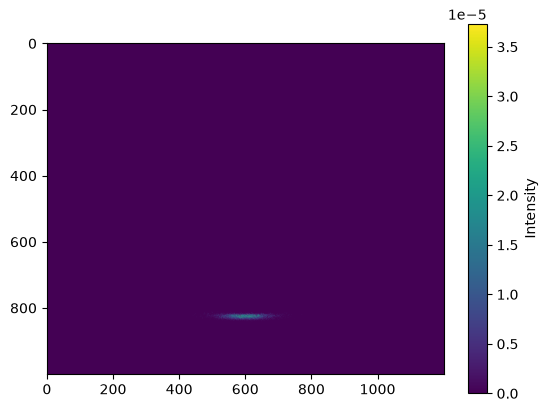

{'cam_total_intensity': {'value': 0.0, 'timestamp': 1785901081.5501316}, 'cam_beam_flux': {'value': 0.0, 'timestamp': 1785901081.5501468}, 'cam_mean_intensity': {'value': 0.0, 'timestamp': 1785901081.5501664}, 'cam_beam_area_px': {'value': 1200000.0, 'timestamp': 1785901081.5501564}, 'cam_center_x': {'value': 0.0, 'timestamp': 1785901081.5501716}, 'cam_center_y': {'value': 0.0, 'timestamp': 1785901081.550176}, 'cam_size_x': {'value': 1000.0, 'timestamp': 1785901081.5501804}, 'cam_size_y': {'value': 1000.0, 'timestamp': 1785901081.5501842}, 'cam_beam_size': {'value': 1000.0, 'timestamp': 1785901081.5501878}, 'cam_power_density': {'value': 0.0, 'timestamp': 1785901081.550191}}


In [9]:
plt.imshow(cam._get_image())
plt.colorbar(label='Intensity')
plt.show()

print(cam.read())

In [10]:
db = tiled_client[uid]
beam_center_y = db['primary']['cam_center_y'].read()
beam_center_x = db['primary']['cam_center_x'].read()
# add beamline status to supplemental data
print(f"Beam center: ({beam_center_x}, {beam_center_y})")

Beam center: ([0.], [0.])


In [12]:
cam._beam_metrics(cam._get_image())

{'total_intensity': 0.02129655405694881,
 'beam_flux': 0.019017796849085777,
 'beam_area_px': 1993.0,
 'mean_intensity': 9.54229646216045e-06,
 'center_x': 599.3656487788394,
 'center_y': 825.2701837548741,
 'size_x': np.float64(43.31170735485877),
 'size_y': np.float64(4.5430065343694785),
 'beam_size': np.float64(43.54931575081577),
 'power_density': np.float64(9.665215426232168e-05)}

In [13]:
## There seems to be rounding errors occuring here

from bluesky.plans import scan
uid = RE(scan([cam], dof_m1_rel_pitch_deg, -0.00005, 0.00005, 5))



Transient Scan ID: 2     Time: 2026-08-04 20:38:51
Persistent Unique Scan ID: '536f816e-afbc-4389-bd54-6b0b1ff8b96b'
New stream: 'primary'
+-----------+------------+----------------------+---------------------+---------------+--------------------+
|   seq_num |       time | dof_m1_rel_pitch_deg | cam_total_intensity | cam_beam_flux | cam_mean_intensity |
+-----------+------------+----------------------+---------------------+---------------+--------------------+
|         1 | 20:38:52.8 |                   -0 |               0.000 |         0.000 |              0.000 |
|         2 | 20:38:54.3 |                   -0 |               0.000 |         0.000 |              0.000 |
|         3 | 20:38:55.9 |                    0 |             106.731 |       100.292 |              1.320 |
|         4 | 20:38:57.3 |                    0 |               0.000 |         0.000 |              0.000 |
|         5 | 20:38:58.8 |                    0 |               0.000 |         0.000 |         

In [14]:
# smaller range, always work
from bluesky.plans import scan
uid = RE(scan([cam], dof_m1_rel_pitch_deg, -0.00001, 0.00001, 5))



Transient Scan ID: 3     Time: 2026-08-04 20:39:03
Persistent Unique Scan ID: '95b17440-e7d7-441c-a4ec-58966037dfa1'
New stream: 'primary'
+-----------+------------+----------------------+---------------------+---------------+--------------------+
|   seq_num |       time | dof_m1_rel_pitch_deg | cam_total_intensity | cam_beam_flux | cam_mean_intensity |
+-----------+------------+----------------------+---------------------+---------------+--------------------+
|         1 | 20:39:04.9 |                   -0 |              28.061 |        24.016 |              1.264 |
|         2 | 20:39:06.4 |                   -0 |              81.823 |        74.706 |              1.383 |
|         3 | 20:39:07.9 |                    0 |              88.104 |        81.508 |              1.381 |
|         4 | 20:39:09.4 |                    0 |              45.148 |        43.266 |              1.202 |
|         5 | 20:39:10.9 |                    0 |               5.592 |         5.564 |         

Text(0, 0.5, 'Vertical beam center position [pixels]')

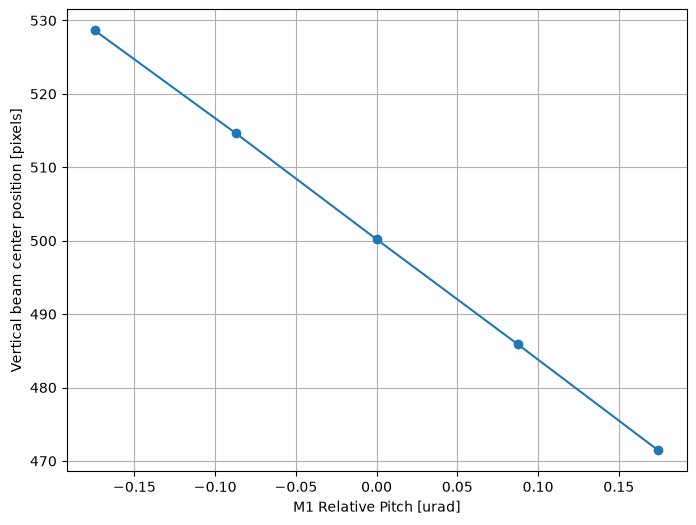

In [15]:
uid = '5bbdd454-c942-4e67-aa1c-fb9f80340821'
db = tiled_client[uid]
beam_center_y = db['primary']['cam_center_y'].read()
beam_center_x = db['primary']['cam_center_x'].read()
pitch_deg = db['primary']['dof_m1_rel_pitch_deg'].read()
power_density = db['primary']['cam_power_density'].read()

plt.figure(figsize=(8, 6))
plt.plot((pitch_deg)*np.pi/180*1e6, beam_center_y, 'o-', label='Beam Center X [pixels]')
plt.grid()
plt.xlabel('M1 Relative Pitch [urad]')
plt.ylabel('Vertical beam center position [pixels]')

## Deploying blop 1.0.0 beamline optimization

In [16]:
import blop
print('Blop version:', blop.__version__)

Blop version: 1.0.0


In [17]:
from blop.ax import Agent, RangeDOF, Objective

# dof_m1_rel_pitch_deg = EpicsSignal(PREFIX + 'DOF:M1_REL_PITCH_DEG', name='dof_m1_rel_pitch_deg')
# dof_m1_bending_m = EpicsSignal(PREFIX + 'DOF:M1_BENDING_M', name='dof_m1_bending_m')
# dof_mono_height_m = EpicsSignal(PREFIX + 'DOF:MONO_HEIGHT_M', name='dof_mono_height_m')
# dof_mono_angle_rel_angle_deg = EpicsSignal(PREFIX + 'DOF:MONO_ANGLE_REL_ANGLE_DEG', name='dof_mono_angle_rel_angle_deg')
# dof_hexapod_rel_x_m = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_X_M', name='dof_hexapod_rel_x_m')
# dof_hexapod_rel_y_m = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_Y_M', name='dof_hexapod_rel_y_m')
# dof_hexapod_rel_z_m = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_Z_M', name='dof_hexapod_rel_z_m')
# dof_hexapod_rel_Rx_deg = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_RX_DEG', name='dof_hexapod_rel_Rx_deg')
# dof_hexapod_rel_Ry_deg = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_RY_DEG', name='dof_hexapod_rel_Ry_deg')
# dof_hexapod_rel_Rz_deg = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_RZ_DEG', name='dof_hexapod_rel_Rz_deg')


from blop.ax import Agent, RangeDOF, Objective


dofs = [
    # DOF(movable=beamline.kbv_dsv, type="continuous", search_domain=(-5.0, 5.0)),
    # DOF(movable=beamline.kbv_usv, type="continuous", search_domain=(-5.0, 5.0)),
    # DOF(movable=beamline.kbh_dsh, type="continuous", search_domain=(-5.0, 5.0)),
    # DOF(movable=beamline.kbh_ush, type="continuous", search_domain=(-5.0, 5.0)),
    #DOF(movable=mono_angle, type="continuous", search_domain=(20, 22)),
    RangeDOF(actuator=dof_m1_rel_pitch_deg,  bounds=(-0.00001, 0.00001), parameter_type="float"), 
    RangeDOF(actuator=dof_m1_bending_m, bounds=(2000, 2800), parameter_type="float"),]

objectives = [
    # Objective(name="bl_det_sum", target="max"),
    # Objective(name="bl_det_wid_x", target="min"),
    # Objective(name="bl_det_wid_y", target="min"),
    #Objective(name="beamstop", target="min"),
    
    ## that is a very poor idea my friend
    #Objective(name="cam_beam_flux", target="max"),
    #Objective(name="cam_size_x", target="min"),
    #Objective(name="cam_size_y", target="min"),

    Objective(name="cam_power_density", minimize=False),
]

import numpy as np
from tiled.client.container import Container
from blop.protocols import EvaluationFunction

class PowerDensityEvaluation(EvaluationFunction):
    """Evaluation function for the M1-pitch / M1-bending optimization.

    `cam_power_density` is already computed upstream (device-level PV),
    so this just reads it back aligned to each suggestion's UID — the
    same job DetectorEvaluation does for `fwhm`/`intensity`, but without
    needing to reprocess an image ourselves.
    """

    def __init__(self, tiled_client: Container):
        self.tiled_client = tiled_client

    def __call__(self, uid, suggestions):
        print("DEBUG uid type:", type(uid), "value:", repr(uid))
        print("DEBUG suggestions:", suggestions)
        run = self.tiled_client[uid]

        # Suggestion IDs in submission order, from the start doc metadata
        suggestion_ids = [
            s["_id"] for s in run.metadata["start"]["blop_suggestions"]
        ]

        power_density = np.asarray(run["primary/cam_power_density"].read())

        outcomes = []
        for idx, sid in enumerate(suggestion_ids):
            value = float(power_density[idx])

            # Guard against dropped/bad readings, mirroring how
            # DetectorEvaluation falls back to a penalty instead of
            # propagating NaN into the optimizer.
            if not np.isfinite(value):
                value = 0.0  # no signal -> worst case for a "maximize" objective

            outcomes.append({
                "_id": sid,
                "cam_power_density": value,
            })

        return outcomes


evaluation_function = PowerDensityEvaluation(tiled_client)

[INFO 08-04 20:39:23] ax.storage.sqa_store.with_db_settings_base: Ax SQL storage initialized with SQLAlchemy 2.0.51


In [18]:
agent = Agent(
    sensors=[cam],
    dofs=dofs,
    objectives=objectives,
    evaluation_function=evaluation_function,
)

In [ ]:
RE(agent.optimize(1, n_points=10))



Transient Scan ID: 2     Time: 2026-08-04 16:38:19
Persistent Unique Scan ID: '3aa21142-55c8-4d40-90f5-922a0508ff19'


╭───────────────────────────────────────────────── Optimization ──────────────────────────────────────────────────╮
│ Optimizer  AxOptimizer                                                                                          │
│ Actuators  dof_m1_rel_pitch_deg, dof_m1_bending_m                                                               │
│ Sensors    cam                                                                                                  │
│ Iterations 1  Points/iter 10                                                                                    │
│ Run UID    3aa21142-55c8-4d40-90f5-922a0508ff19                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[INFO 08-04 16:38:19] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol', use_existing_trials_for_initialization=True), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, generator_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')], suggested_experiment_status=ExperimentStatus.INITIALIZATION, pausing_criteria=[MaxTrialsAwaitingData(threshold=5)]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, generator_key_override=None)], transition_criteria=None, suggested_experiment_status=ExperimentStatus.OPTIMIZATION, pausing_criteria=None)]) chosen based on user input and problem structure.


[INFO 08-04 16:38:19] ax.api.client: Generated new trial 0 with parameters {'dof_m1_rel_pitch_deg': 0.0, 'dof_m1_bending_m': 2400.0} using GenerationNode CenterOfSearchSpace.
[INFO 08-04 16:38:19] ax.api.client: Generated new trial 1 with parameters {'dof_m1_rel_pitch_deg': -8e-06, 'dof_m1_bending_m': 2063.766485} using GenerationNode Sobol.
[INFO 08-04 16:38:19] ax.api.client: Generated new trial 2 with parameters {'dof_m1_rel_pitch_deg': 1e-06, 'dof_m1_bending_m': 2491.613339} using GenerationNode Sobol.
[INFO 08-04 16:38:19] ax.api.client: Generated new trial 3 with parameters {'dof_m1_rel_pitch_deg': 7e-06, 'dof_m1_bending_m': 2200.646291} using GenerationNode Sobol.
[INFO 08-04 16:38:19] ax.api.client: Generated new trial 4 with parameters {'dof_m1_rel_pitch_deg': -4e-06, 'dof_m1_bending_m': 2628.171126} using GenerationNode Sobol.
[INFO 08-04 16:38:19] ax.api.client: Generated new trial 5 with parameters {'dof_m1_rel_pitch_deg': -0.0, 'dof_m1_bending_m': 2349.64977} using Generat



Transient Scan ID: 3     Time: 2026-08-04 16:38:19
Persistent Unique Scan ID: '757d6b3b-4e9f-4309-8af7-0eea139f2b70'
A 'deferred pause' has been requested. The RunEngine will pause at the next checkpoint. To pause immediately, hit Ctrl+C again in the next 10 seconds.
Deferred pause acknowledged. Continuing to checkpoint.
